# S1 시뮬레이션 — supIPM / EIPM 추정량 검증

사양: `claude_md/S1_SPEC.md`.  **목적**: supIPM 추정량(커널 + grid)이 참값에 수렴하는지 확인.

### 모형
$$S \sim N(0,1),\qquad Z\mid S=s \sim N\big(\mu(s),\ \sigma_c^2\big),\qquad \sigma_c^2 = 1-\mathrm{Var}(\mu(S))$$

* `linear` : $\mu(s)=\lambda s$ — 참값 공식 검증용
* `bump` : $\mu(s)=\kappa\exp\!\big(-(s-s_0)^2/2\tau^2\big)$, 기본 $\kappa=1.2,\ s_0=0.7,\ \tau=0.2$ — **주 실험**

판별자족이 1-Lipschitz 이므로 IPM = $W_1$, 1차원에서
$$W_1(s)=\int |F_s(u)-F(u)|\,du,\qquad F_s(u)=\Phi\!\Big(\frac{u-\mu(s)}{\sigma_c}\Big),\quad F(u)=\mathbb{E}_S[F_S(u)].$$

### 실행 구조 (Slurm)


프로젝트 규칙(`CLAUDE.md`)에 따라 계산은 **항상 Slurm 할당 안에서** 돈다. 이 노트북은 두 경로를 자동 판별한다.

| 상황 | 동작 |
|---|---|
| 할당 **밖**에서 노트북 실행 (`SLURM_JOB_ID` 없음) | 설정 하나당 `srun --partition=idea --cpus-per-task=2 ... s1_worker.py` 잡을 띄움 |
| 이미 할당 **안** (`srun --pty bash` 안에서 jupyter 등) | 중첩 job step 을 만들지 않고 그 할당 안에서 일반 subprocess 로 실행 |

권장 실행 방법:

```bash
# (a) 대화형
srun --cpus-per-task=16 --partition=idea --time=04:00:00 --pty bash
jupyter lab            # 또는 아래 (b)

# (b) 통째로 실행
cd "Fair representation/sup_IPM/notebook"
srun --cpus-per-task=16 --partition=idea --time=04:00:00 \
    /usr/local/miniconda3/envs/nine/bin/jupyter nbconvert --to notebook --execute \
    --inplace --ExecutePreprocessor.timeout=7200 s1.ipynb
```

노트북은 `s1_core.py` / `s1_worker.py` / `s1_runner.py` 를 **직접 써 내려간다**(`%%writefile`).
즉 이 노트북이 유일한 소스이고, 세 `.py` 는 산출물이다. 결과는 `results/*.npz` 에 캐시되므로
재실행은 공짜다 (`--force` 로 무시 가능).

## 0. 환경 / 경로

In [1]:
import os, sys, json, subprocess, importlib, warnings, time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import norm

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.30, "axes.axisbelow": True,
                     "figure.autolayout": True, "legend.frameon": False})

NB_DIR = os.path.abspath(os.getcwd())          # jupyter/nbconvert cwd = 노트북 위치
for sub in ("results", "logs", "figures"):
    os.makedirs(os.path.join(NB_DIR, sub), exist_ok=True)
if sys.path[0] != NB_DIR:
    sys.path.insert(0, NB_DIR)

print("notebook dir :", NB_DIR)
if os.path.basename(NB_DIR) != "notebook":
    print("  !! cwd 가 노트북 디렉터리가 아닌 것 같습니다 — %%writefile 이 엉뚱한 곳에 씁니다.")
print("python       :", sys.executable)
print("numpy/scipy/mpl:", np.__version__, __import__("scipy").__version__, matplotlib.__version__)
print("SLURM_JOB_ID :", os.environ.get("SLURM_JOB_ID", "(할당 밖 — srun 잡을 띄웁니다)"))
print("SLURM_CPUS_PER_TASK:", os.environ.get("SLURM_CPUS_PER_TASK", "-"), "| os.cpu_count():", os.cpu_count())
print(subprocess.run(["sinfo", "-p", "idea", "-o", "%P %a %D %C %G %t"],
                     capture_output=True, text=True).stdout or "(sinfo 없음)")

notebook dir : /home/ys971217/IPM_research/Fair representation/sup_IPM/notebook
python       : /usr/local/miniconda3/envs/nine/bin/python
numpy/scipy/mpl: 1.26.4 1.10.1 3.9.1
SLURM_JOB_ID : 3082
SLURM_CPUS_PER_TASK: 16 | os.cpu_count(): 48
PARTITION AVAIL NODES CPUS(A/I/O/T) GRES STATE
idea up 1 16/32/0/48 gpu:4 mix



## 1. 모듈 3개 (노트북이 직접 생성)

* `s1_core.py` — 참값 / 추정량 (numpy·scipy 만)
* `s1_worker.py` — 설정 1개의 반복 전부를 돌려 `.npz` 하나로 저장 (Slurm 잡 1개 = 워커 1개)
* `s1_runner.py` — 설정 목록 · srun 디스패치 · 캐시 · 수집

In [2]:
%%writefile s1_core.py
"""S1 simulation core: truth + estimators for supIPM / EIPM.  numpy / scipy only.

Model (spec S1 sec.1)
    S ~ N(0,1),   Z | S=s ~ N(mu(s), sigma_c^2),   sigma_c^2 = 1 - Var(mu(S))
so Var(Z) = 1 exactly.  Two choices of mu:
    linear : mu(s) = lam * s                          (closed-form check)
    bump   : mu(s) = kappa*exp(-(s-s0)^2/(2*tau^2))   (main experiment)

Discriminator class = 1-Lipschitz  =>  IPM(s) = W1(P_{Z|S=s}, P_Z), and in 1-D
    W1(s) = int |F_s(u) - F(u)| du .

NOTE this file is generated by s1.ipynb (a %%writefile cell); edit the notebook,
not this file.
"""
import os
import warnings

import numpy as np
from numpy.polynomial.hermite_e import hermegauss
from scipy.special import ndtr          # standard normal CDF, ~5x faster than norm.cdf
from scipy.stats import norm

# ----------------------------------------------------------------- constants
ALPHA = 0.05
Z_TRIM = float(norm.ppf(1 - ALPHA / 2))            # 1.959964...  trimming |s| <= z
U_GRID = np.linspace(-8.0, 8.0, 4001)              # spec sec.2: u integration grid
S_GRID = np.linspace(-Z_TRIM, Z_TRIM, 5001)        # spec sec.2: s grid for the sup
GH_NODES = 101                                     # spec sec.2: Gauss-Hermite nodes
N_EIPM = 500                                       # spec sec.3: MC size for EIPM_hat
JS_DEFAULT = (2, 3, 5, 10, 20)                     # spec sec.4 C3
MIN_BIN_COUNT = 10                                 # spec sec.3: drop bins with < 10 obs


# --------------------------------------------------------------------- model
def mu_of(kind, **p):
    """Return the mean function mu(.) for the given setting."""
    if kind == "linear":
        lam = float(p.get("lam", 0.5))
        return lambda s: lam * np.asarray(s, dtype=float)
    if kind == "bump":
        kappa = float(p.get("kappa", 1.2))
        s0 = float(p.get("s0", 0.7))
        tau = float(p.get("tau", 0.2))
        return lambda s: kappa * np.exp(-(np.asarray(s, dtype=float) - s0) ** 2 / (2 * tau ** 2))
    raise ValueError(f"unknown mu kind: {kind}")


def var_mu_exact(kind, **p):
    """Var(mu(S)) in closed form, S ~ N(0,1).

    bump: E[exp(-(S-s0)^2/(2 t^2))] = t/sqrt(1+t^2) * exp(-s0^2/(2(1+t^2))),
    applied with t = tau (first moment) and t = tau/sqrt(2) (second moment).
    Using the exact value (rather than quadrature) makes Var(Z) = 1 exactly.
    """
    if kind == "linear":
        return float(p.get("lam", 0.5)) ** 2
    if kind == "bump":
        kappa = float(p.get("kappa", 1.2))
        s0 = float(p.get("s0", 0.7))
        tau = float(p.get("tau", 0.2))
        g = lambda t: t / np.sqrt(1 + t ** 2) * np.exp(-s0 ** 2 / (2 * (1 + t ** 2)))
        m1 = kappa * g(tau)
        m2 = kappa ** 2 * g(tau / np.sqrt(2))
        return float(m2 - m1 ** 2)
    raise ValueError(f"unknown mu kind: {kind}")


def make_model(kind="bump", **p):
    var_mu = var_mu_exact(kind, **p)
    if var_mu >= 1.0:
        raise ValueError(f"Var(mu(S)) = {var_mu:.4f} >= 1 -> sigma_c^2 <= 0")
    return {"kind": kind, "params": dict(p), "mu": mu_of(kind, **p),
            "var_mu": var_mu, "sigma_c": float(np.sqrt(1.0 - var_mu))}


def model_tag(model):
    ps = "_".join(f"{k}{v:g}" for k, v in sorted(model["params"].items()))
    return f"{model['kind']}" + (f"_{ps}" if ps else "")


# ---------------------------------------------------------------- quadrature
def gh_quad(m=GH_NODES):
    """Gauss-Hermite (probabilists') nodes/weights for E_S[f(S)], S ~ N(0,1).

    numpy's hermegauss emits harmless divide/overflow warnings while building the
    weights; the returned weights are finite and sum to sqrt(2*pi) for m <= ~300.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        x, w = hermegauss(m)
    if not np.isfinite(w).all():
        raise RuntimeError(f"hermegauss({m}) produced non-finite weights")
    return x, w / np.sqrt(2 * np.pi)                 # weights now sum to 1


def trap_quad(m=20001, lo=-10.0, hi=10.0):
    """Dense trapezoid reference rule for E_S[f(S)] (accuracy cross-check)."""
    x = np.linspace(lo, hi, m)
    w = norm.pdf(x) * (x[1] - x[0])
    w[0] *= 0.5
    w[-1] *= 0.5
    return x, w / w.sum()


# --------------------------------------------------------------------- truth
def marginal_cdf(model, u=U_GRID, quad=None, block=2048):
    """F(u) = E_S[ Phi((u - mu(S))/sigma_c) ]."""
    x, w = gh_quad() if quad is None else quad
    m = model["mu"](x)
    sc = model["sigma_c"]
    F = np.zeros(u.size)
    for i in range(0, m.size, block):
        j = min(i + block, m.size)
        F += w[i:j] @ ndtr((u[None, :] - m[i:j, None]) / sc)
    return F


def w1_true_at_mu(m_vals, sigma_c, F, u=U_GRID, block=512):
    """W1(s) = int |Phi((u-mu(s))/sigma_c) - F(u)| du, vectorised over mu(s)."""
    m_vals = np.atleast_1d(np.asarray(m_vals, dtype=float))
    du = u[1] - u[0]
    out = np.empty(m_vals.size)
    for i in range(0, m_vals.size, block):
        j = min(i + block, m_vals.size)
        D = np.abs(ndtr((u[None, :] - m_vals[i:j, None]) / sigma_c) - F[None, :])
        out[i:j] = np.trapz(D, dx=du, axis=1)
    return out


def truth(model, u=U_GRID, s_grid=S_GRID, quad=None):
    """supIPM_true (max over the trimmed s grid) and EIPM_true (phi-weighted mean)."""
    F = marginal_cdf(model, u, quad)
    w1 = w1_true_at_mu(model["mu"](s_grid), model["sigma_c"], F, u)
    phi = norm.pdf(s_grid)
    return {"s_grid": s_grid, "w1": w1, "F": F,
            "supipm": float(w1.max()), "s_argmax": float(s_grid[w1.argmax()]),
            "eipm": float(np.trapz(w1 * phi, s_grid) / np.trapz(phi, s_grid))}


def w1_linear_closed_form(s, lam, sigma_c):
    """Spec sec.2: with b = sigma_c - 1 and a = lam*s,
        W1(s) = |b| sqrt(2/pi) exp(-a^2/(2b^2)) + a (2 Phi(a/|b|) - 1)
    (this is E|N(a, b^2)|; the two normal CDFs cross exactly once)."""
    b = abs(sigma_c - 1.0)
    a = lam * np.asarray(s, dtype=float)
    return b * np.sqrt(2 / np.pi) * np.exp(-a ** 2 / (2 * b ** 2)) + a * (2 * ndtr(a / b) - 1)


def truth_cached(model, cache_dir, gh_nodes=GH_NODES, verbose=False):
    """Truth is deterministic -> compute once per model and reuse (also by workers)."""
    os.makedirs(cache_dir, exist_ok=True)
    path = os.path.join(cache_dir, f"truth_{model_tag(model)}_gh{gh_nodes}.npz")
    if os.path.exists(path):
        with np.load(path) as d:
            out = {k: d[k] for k in d.files}
        for k in ("supipm", "eipm", "s_argmax"):
            out[k] = float(out[k])
        return out
    t = truth(model, quad=gh_quad(gh_nodes))
    np.savez_compressed(path, **t)
    if verbose:
        print(f"[truth] computed and cached -> {path}")
    return t


# ----------------------------------------------------------------- estimator
def simulate(n, model, rng):
    s = rng.standard_normal(n)
    z = model["mu"](s) + model["sigma_c"] * rng.standard_normal(n)
    return s, z


def prep(s, z):
    """Sort by z once; the step-function integral is then an exact finite sum."""
    order = np.argsort(z)
    zs = z[order]
    n = z.size
    return {"s_sorted": s[order], "gaps": np.diff(zs), "F_emp": np.arange(1, n + 1) / n, "n": n}


def w1_hat(points, P, h, max_elems=20_000_000):
    """W1_hat(s) for every s in `points` (spec sec.3).

        w_i(s)      = K_h(s-s_i)/sum_j K_h(s-s_j)      (Gaussian kernel)
        F_s_hat(u)  = sum_i w_i(s) 1(z_i <= u),   F_hat(u) = (1/n) sum_i 1(z_i <= u)
        W1_hat(s)   = sum_k |F_s_hat - F_hat|(z_(k)) * (z_(k+1) - z_(k))

    The exponent is shifted by its row max before exp() -- an exact rescaling of
    numerator and denominator, which keeps the weights well defined when a grid
    point is far from every s_i.
    """
    pts = np.atleast_1d(np.asarray(points, dtype=float))
    ss, gaps, F_emp, n = P["s_sorted"], P["gaps"], P["F_emp"], P["n"]
    block = max(1, int(max_elems // n))
    out = np.empty(pts.size)
    for i in range(0, pts.size, block):
        j = min(i + block, pts.size)
        e = -0.5 * ((pts[i:j, None] - ss[None, :]) / h) ** 2
        e -= e.max(axis=1, keepdims=True)
        Kw = np.exp(e)
        W = Kw / Kw.sum(axis=1, keepdims=True)
        F_cond = np.cumsum(W, axis=1)
        out[i:j] = np.abs(F_cond[:, :-1] - F_emp[:-1]) @ gaps
    return out


def bandwidth(n, c):
    return c * n ** (-1 / 5)


def grid_of(ratio, h):
    """Equispaced grid on [-z, z] with spacing delta_G such that delta_G/h = ratio."""
    G = int(np.ceil(2 * Z_TRIM / (ratio * h))) + 1
    return np.linspace(-Z_TRIM, Z_TRIM, G), G


def binning_sup(P, Js=JS_DEFAULT, min_count=MIN_BIN_COUNT, trim=False):
    """Baseline (spec sec.3): split s into J equal-frequency bins, W1 between each
    bin's empirical z-distribution and the overall empirical distribution, take max.
    Bins with fewer than `min_count` observations are dropped.

    trim=False is the spec's version (quantiles over the whole sample).  trim=True
    is a diagnostic: quantiles and bin membership restricted to |s| <= Z_TRIM, i.e.
    the same region the kernel grid covers.  The reference F_hat always uses all n.
    """
    ss, gaps, F_emp, n = P["s_sorted"], P["gaps"], P["F_emp"], P["n"]
    use = np.abs(ss) <= Z_TRIM if trim else np.ones(n, dtype=bool)
    s_use = ss[use]
    out = {}
    for J in Js:
        q = np.quantile(s_use, np.linspace(0, 1, J + 1))
        b = np.searchsorted(q[1:-1], ss, side="right")          # bin index in 0..J-1
        M = np.zeros((J, n))
        M[b, np.arange(n)] = use
        cnt = M.sum(axis=1)
        keep = cnt >= min_count
        if not keep.any():
            out[J] = float("nan")
            continue
        F_bin = np.cumsum(M[keep] / cnt[keep, None], axis=1)
        out[J] = float((np.abs(F_bin[:, :-1] - F_emp[:-1]) @ gaps).max())
    return out


def run_rep(n, c, ratio, seed, model, js=JS_DEFAULT, n_eipm=N_EIPM, with_binning=True):
    """One replication: draw data, return every estimate computed on it.

    The rng stream is (s, z, EIPM subsample) in that order, so two configurations
    sharing (n, seed) see *identical* data and identical EIPM evaluation points
    -> the comparisons in C2/C3 are exactly paired.
    """
    rng = np.random.default_rng(seed)
    s, z = simulate(n, model, rng)
    inside = np.flatnonzero(np.abs(s) <= Z_TRIM)
    sel = rng.choice(inside, size=min(n_eipm, inside.size), replace=False)

    h = bandwidth(n, c)
    grid, G = grid_of(ratio, h)
    P = prep(s, z)
    rep = {"sup": float(w1_hat(grid, P, h).max()),
           "eipm": float(w1_hat(s[sel], P, h).mean()),
           "G": G, "h": h, "n_eipm": int(sel.size)}
    if with_binning:
        rep["bins"] = binning_sup(P, js, trim=False)
        rep["bins_trim"] = binning_sup(P, js, trim=True)
    return rep


def seed_of(r, seed0=1000, step=7919):
    """Spec sec.4: seed = 1000 + 7919*r, identical across configurations."""
    return seed0 + step * r

Overwriting s1_core.py


In [3]:
%%writefile s1_worker.py
"""S1 worker: run all replications of ONE configuration and write one .npz.

Launched by s1_runner.py (one Slurm job step per configuration).  Every estimator
that can share a data draw is computed here, so C1/C2/C3 read from the same file
whenever they share (n, c, ratio) -- the comparisons stay exactly paired.

    python s1_worker.py --out results/K_n10000_c1_r0.5.npz --n 10000 --c 1.0 \
        --ratio 0.5 --reps 100 --kind bump --kappa 1.2 --s0 0.7 --tau 0.2

NOTE this file is generated by s1.ipynb (a %%writefile cell); edit the notebook.
"""
import argparse
import json
import os
import sys
import time

import numpy as np

sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
import s1_core as C


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--out", required=True)
    ap.add_argument("--n", type=int, required=True)
    ap.add_argument("--c", type=float, required=True)
    ap.add_argument("--ratio", type=float, required=True)
    ap.add_argument("--reps", type=int, default=100)
    ap.add_argument("--kind", default="bump")
    ap.add_argument("--kappa", type=float, default=1.2)
    ap.add_argument("--s0", type=float, default=0.7)
    ap.add_argument("--tau", type=float, default=0.2)
    ap.add_argument("--lam", type=float, default=0.5)
    ap.add_argument("--js", default=",".join(str(j) for j in C.JS_DEFAULT))
    ap.add_argument("--n-eipm", type=int, default=C.N_EIPM)
    ap.add_argument("--gh-nodes", type=int, default=C.GH_NODES)
    ap.add_argument("--seed0", type=int, default=1000)
    ap.add_argument("--seed-step", type=int, default=7919)
    ap.add_argument("--no-binning", action="store_true")
    a = ap.parse_args()

    params = {"lam": a.lam} if a.kind == "linear" else {"kappa": a.kappa, "s0": a.s0, "tau": a.tau}
    model = C.make_model(a.kind, **params)
    js = tuple(int(j) for j in a.js.split(",") if j)

    cache = os.path.dirname(os.path.abspath(a.out))
    os.makedirs(cache, exist_ok=True)
    t = C.truth_cached(model, cache, a.gh_nodes)
    sup_true, eipm_true = t["supipm"], t["eipm"]

    print(f"[worker] n={a.n} c={a.c} ratio={a.ratio} reps={a.reps} "
          f"sigma_c={model['sigma_c']:.6f} sup_true={sup_true:.6f} eipm_true={eipm_true:.6f} "
          f"host={os.uname().nodename} job={os.environ.get('SLURM_JOB_ID', '-')}", flush=True)

    sup = np.empty(a.reps)
    eipm = np.empty(a.reps)
    nbin = len(js)
    bins = np.full((nbin, a.reps), np.nan)
    bins_trim = np.full((nbin, a.reps), np.nan)
    G = h = None
    t0 = time.time()
    for r in range(a.reps):
        rep = C.run_rep(a.n, a.c, a.ratio, C.seed_of(r, a.seed0, a.seed_step), model,
                        js=js, n_eipm=a.n_eipm, with_binning=not a.no_binning)
        sup[r], eipm[r] = rep["sup"], rep["eipm"]
        if not a.no_binning:
            for k, J in enumerate(js):
                bins[k, r] = rep["bins"][J]
                bins_trim[k, r] = rep["bins_trim"][J]
        G, h = rep["G"], rep["h"]
        if (r + 1) % 25 == 0:
            print(f"[worker]   rep {r + 1}/{a.reps}  {time.time() - t0:.1f}s", flush=True)

    meta = {"n": a.n, "c": a.c, "ratio": a.ratio, "reps": a.reps, "kind": a.kind,
            "params": params, "js": list(js), "n_eipm": a.n_eipm, "gh_nodes": a.gh_nodes,
            "seed0": a.seed0, "seed_step": a.seed_step, "sigma_c": model["sigma_c"],
            "elapsed_s": time.time() - t0}
    tmp = a.out + ".tmp.npz"
    np.savez_compressed(tmp, sup_hat=sup, eipm_hat=eipm, bin_hat=bins, bin_trim_hat=bins_trim,
                        js=np.array(js), sup_true=sup_true, eipm_true=eipm_true,
                        n=a.n, c=a.c, ratio=a.ratio, reps=a.reps, G=G, h=h,
                        sigma_c=model["sigma_c"], meta=json.dumps(meta))
    os.replace(tmp, a.out)                       # atomic: a partial file never looks done
    err = sup - sup_true
    print(f"[worker] done in {time.time() - t0:.1f}s  G={G} h={h:.4f}  "
          f"sup bias={err.mean():+.4f} rmse={np.sqrt((err ** 2).mean()):.4f}  -> {a.out}", flush=True)


if __name__ == "__main__":
    main()

Overwriting s1_worker.py


In [4]:
%%writefile s1_runner.py
"""S1 runner: build the configuration list, dispatch one Slurm job step per
configuration, collect the .npz results.

Two dispatch modes, chosen automatically (project rule: compute always runs
inside a Slurm allocation, never straight on the shell):

  * outside an allocation  -> each configuration is launched as its own
        srun --partition=idea --cpus-per-task=K --time=... python s1_worker.py ...
  * already inside one (e.g. the notebook itself was started under
    `srun --pty bash` or `srun ... jupyter`) -> workers run as plain
    subprocesses of this process, so they stay inside the granted allocation
    and no nested job step is created.

Everything is cache-aware: a configuration whose .npz already holds the
requested number of replications is skipped, so re-running is free.

NOTE this file is generated by s1.ipynb (a %%writefile cell); edit the notebook.
"""
import json
import os
import shutil
import subprocess
import sys
import time

import numpy as np

HERE = os.path.dirname(os.path.abspath(__file__))
sys.path.insert(0, HERE)
import s1_core as C

PY = os.environ.get("S1_PYTHON", "/usr/local/miniconda3/envs/nine/bin/python")
RESULTS = os.path.join(HERE, "results")
LOGS = os.path.join(HERE, "logs")
FIGURES = os.path.join(HERE, "figures")
PARTITION = os.environ.get("S1_PARTITION", "idea")
TIME_LIMIT = os.environ.get("S1_TIME", "01:00:00")

IN_ALLOCATION = bool(os.environ.get("SLURM_JOB_ID"))
HAVE_SRUN = shutil.which("srun") is not None

# ------------------------------------------------------------------- design
BUMP = {"kind": "bump", "kappa": 1.2, "s0": 0.7, "tau": 0.2}
REPS = 100
N_LIST = [500, 1000, 2000, 5000, 10000, 20000]      # C1
RATIO_LIST = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]        # C2
JS = list(C.JS_DEFAULT)                             # C3
C_BASE, RATIO_BASE, N_BASE = 1.0, 0.5, 10000        # spec's fixed values
C_EXTRA = [0.25, 0.5]                               # C1b (supplementary, not in the spec)


def job(n, c, ratio, model=None, reps=REPS):
    model = model or BUMP
    p = {k: v for k, v in model.items() if k != "kind"}
    mt = C.model_tag({"kind": model["kind"], "params": p})
    tag = f"{mt}__n{n}_c{c:g}_r{ratio:g}"
    return {"tag": tag, "n": n, "c": c, "ratio": ratio, "reps": reps,
            "model": model, "out": os.path.join(RESULTS, tag + ".npz")}


def _dedup(js):
    seen, out = set(), []
    for j in js:
        if j["tag"] not in seen:
            seen.add(j["tag"])
            out.append(j)
    return out


def jobs_c1():
    return [job(n, C_BASE, RATIO_BASE) for n in N_LIST]


def jobs_c2():
    return [job(N_BASE, C_BASE, r) for r in RATIO_LIST]


def jobs_c3():
    return [job(N_BASE, C_BASE, RATIO_BASE)]        # binning shares the C1/C2 draws


def jobs_c1b():
    return [job(n, c, RATIO_BASE) for c in C_EXTRA for n in N_LIST]


def all_jobs(include_supplementary=True):
    js = jobs_c1() + jobs_c2() + jobs_c3()
    if include_supplementary:
        js += jobs_c1b()
    return _dedup(js)


# ------------------------------------------------------------------ caching
def is_done(j):
    if not os.path.exists(j["out"]):
        return False
    try:
        with np.load(j["out"], allow_pickle=False) as d:
            return int(d["reps"]) >= j["reps"] and d["sup_hat"].size >= j["reps"]
    except Exception:
        return False


def load(j):
    with np.load(j["out"], allow_pickle=False) as d:
        out = {k: d[k] for k in d.files if k != "meta"}
        out["meta"] = json.loads(str(d["meta"])) if "meta" in d.files else {}
    return out


def load_many(js):
    return {j["tag"]: load(j) for j in js}


# ---------------------------------------------------------------- dispatch
def _cmd(j, cpus):
    m = j["model"]
    args = [PY, "-u", os.path.join(HERE, "s1_worker.py"),
            "--out", j["out"], "--n", str(j["n"]), "--c", str(j["c"]),
            "--ratio", str(j["ratio"]), "--reps", str(j["reps"]),
            "--kind", m["kind"], "--js", ",".join(str(x) for x in JS)]
    for k in ("kappa", "s0", "tau", "lam"):
        if k in m:
            args += [f"--{k}", str(m[k])]
    if IN_ALLOCATION or not HAVE_SRUN:
        return args
    name = f"s1-n{j['n']}c{j['c']:g}r{j['ratio']:g}"          # short + unique in squeue
    return ["srun", f"--partition={PARTITION}", f"--cpus-per-task={cpus}",
            f"--time={TIME_LIMIT}", f"--job-name={name}"] + args


def launch(jobs, max_concurrent=None, cpus=2, force=False, dry=False, poll=3.0):
    """Run every not-yet-finished configuration, at most `max_concurrent` at a time."""
    os.makedirs(RESULTS, exist_ok=True)
    os.makedirs(LOGS, exist_ok=True)
    todo = list(jobs) if force else [j for j in jobs if not is_done(j)]
    if max_concurrent is None:
        budget = int(os.environ.get("SLURM_CPUS_PER_TASK", 0)) or (os.cpu_count() or 4)
        max_concurrent = max(1, min(8, budget // cpus)) if IN_ALLOCATION else 8
    mode = ("in-allocation subprocesses" if IN_ALLOCATION else
            "srun job steps" if HAVE_SRUN else "plain subprocesses (no Slurm found!)")
    print(f"[runner] {len(todo)}/{len(jobs)} to run ({len(jobs) - len(todo)} cached) | "
          f"mode={mode} | max_concurrent={max_concurrent} cpus/job={cpus}", flush=True)
    if dry:
        for j in todo:
            print("  would run:", " ".join(_cmd(j, cpus)))
        return []
    if not todo:
        return []

    env = dict(os.environ, OMP_NUM_THREADS=str(cpus), MKL_NUM_THREADS=str(cpus),
               OPENBLAS_NUM_THREADS=str(cpus))
    queue, running, failed = list(todo), [], []
    t0 = time.time()
    while queue or running:
        for pr, j, fh in running[:]:
            if pr.poll() is None:
                continue
            fh.close()
            running.remove((pr, j, fh))
            ok = is_done(j)
            if not ok:
                failed.append(j["tag"])
            print(f"[runner] {'done ' if ok else 'FAILED'} {j['tag']} (exit {pr.returncode}) | "
                  f"left={len(queue)} running={len(running)} elapsed={time.time() - t0:.0f}s", flush=True)
        while queue and len(running) < max_concurrent:
            j = queue.pop(0)
            fh = open(os.path.join(LOGS, j["tag"] + ".log"), "w")
            pr = subprocess.Popen(_cmd(j, cpus), cwd=HERE, env=env,
                                  stdout=fh, stderr=subprocess.STDOUT)
            print(f"[runner] start {j['tag']}", flush=True)
            running.append((pr, j, fh))
        if queue or running:
            time.sleep(poll)
    print(f"[runner] finished in {time.time() - t0:.0f}s, failures: {len(failed)}", flush=True)
    if failed:
        print("[runner] check logs:", ", ".join(os.path.join(LOGS, t + '.log') for t in failed))
    return failed


def status(jobs):
    rows = [{"tag": j["tag"], "n": j["n"], "c": j["c"], "ratio": j["ratio"],
             "done": is_done(j)} for j in jobs]
    n_done = sum(r["done"] for r in rows)
    print(f"[runner] {n_done}/{len(rows)} configurations complete")
    return rows


if __name__ == "__main__":
    which = sys.argv[1] if len(sys.argv) > 1 else "all"
    sel = {"c1": jobs_c1, "c2": jobs_c2, "c3": jobs_c3, "c1b": jobs_c1b,
           "all": all_jobs, "spec": lambda: _dedup(jobs_c1() + jobs_c2() + jobs_c3())}[which]()
    launch(sel, dry="--dry" in sys.argv, force="--force" in sys.argv)

Overwriting s1_runner.py


In [5]:
import s1_core, s1_runner
importlib.reload(s1_core); importlib.reload(s1_runner)
import s1_core as C
R = s1_runner

print(f"alpha={C.ALPHA}  z_trim={C.Z_TRIM:.9f}  u-grid={C.U_GRID[0]:g}..{C.U_GRID[-1]:g} "
      f"({C.U_GRID.size} pts, du={C.U_GRID[1]-C.U_GRID[0]:g})")
print(f"s-grid(true)={C.S_GRID.size} pts   GH nodes={C.GH_NODES}   N_EIPM={C.N_EIPM}")
print(f"runner: IN_ALLOCATION={R.IN_ALLOCATION}  HAVE_SRUN={R.HAVE_SRUN}  partition={R.PARTITION}")

alpha=0.05  z_trim=1.959963985  u-grid=-8..8 (4001 pts, du=0.004)
s-grid(true)=5001 pts   GH nodes=101   N_EIPM=500
runner: IN_ALLOCATION=True  HAVE_SRUN=True  partition=idea


## 2. 참값

$F(u)$ 는 Gauss-Hermite 구적(노드 101개), $u$ 적분은 `linspace(-8,8,4001)` 사다리꼴,
$\sup$ 는 trimmed 구간 $[-z,z]$, $z=\Phi^{-1}(1-\alpha/2)$ 위 5001점 최대.

$\sigma_c$ 는 $\mathrm{Var}(\mu(S))$ 의 **닫힌 형태**로 계산한다 (bump 도 닫힌 형태가 있다).
구적으로 구하면 $\mathrm{Var}(Z)=1$ 이 $10^{-3}$ 수준으로 어긋나는데, 이러면 "모형"과 "참값"이
서로 다른 대상을 가리키게 된다. 아래 2.2 에서 구적 오차를 실제로 재서 확인한다.

bump: kappa=1.2 s0=0.7 tau=0.2
  Var(mu(S)) = 0.1240092127   sigma_c = 0.9359437949   Var(Z) = 1.000000000000
  supIPM_true = 1.013972916   (argmax s = +0.7001)
  EIPM_true   = 0.270026720     ratio sup/E = 3.7551


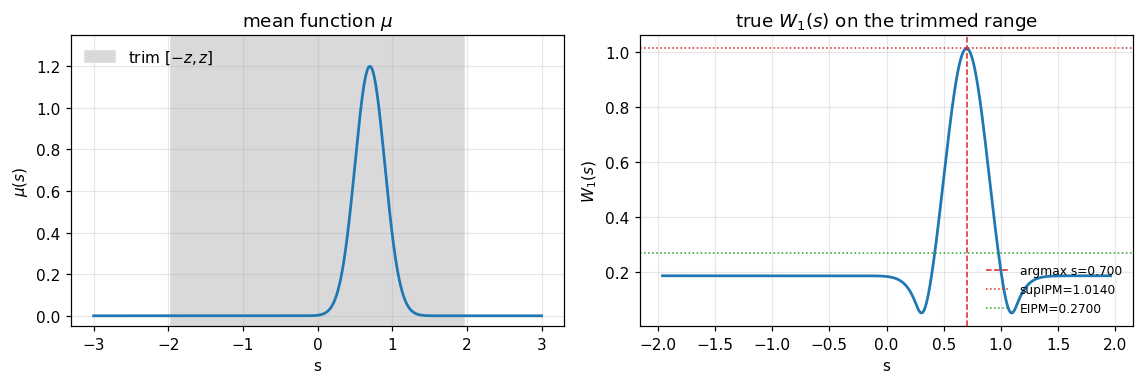


sup 이 구간 내부(s=0.7)에서 달성됨 -> grid 간격 실험(C2)이 의미를 가진다.


In [6]:
model = C.make_model("bump", kappa=1.2, s0=0.7, tau=0.2)
T = C.truth_cached(model, os.path.join(NB_DIR, "results"), verbose=True)

print(f"bump: kappa=1.2 s0=0.7 tau=0.2")
print(f"  Var(mu(S)) = {model['var_mu']:.10f}   sigma_c = {model['sigma_c']:.10f}   "
      f"Var(Z) = {model['var_mu'] + model['sigma_c']**2:.12f}")
print(f"  supIPM_true = {T['supipm']:.9f}   (argmax s = {T['s_argmax']:+.4f})")
print(f"  EIPM_true   = {T['eipm']:.9f}     ratio sup/E = {T['supipm']/T['eipm']:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))
ss = np.linspace(-3, 3, 1201)
ax[0].plot(ss, model["mu"](ss), lw=1.8)
ax[0].fill_between([-C.Z_TRIM, C.Z_TRIM], -0.1, 1.35, color="0.85", zorder=0, label="trim $[-z,z]$")
ax[0].set(xlabel="s", ylabel=r"$\mu(s)$", title=r"mean function $\mu$", ylim=(-0.05, 1.35))
ax[0].legend(loc="upper left")
ax[1].plot(T["s_grid"], T["w1"], lw=1.8)
ax[1].axvline(T["s_argmax"], color="C3", ls="--", lw=1,
              label=f"argmax s={T['s_argmax']:.3f}")
ax[1].axhline(T["supipm"], color="C3", ls=":", lw=1, label=f"supIPM={T['supipm']:.4f}")
ax[1].axhline(T["eipm"], color="C2", ls=":", lw=1, label=f"EIPM={T['eipm']:.4f}")
ax[1].set(xlabel="s", ylabel=r"$W_1(s)$", title=r"true $W_1(s)$ on the trimmed range")
ax[1].legend(loc="lower right", fontsize=8)
fig.savefig(os.path.join(NB_DIR, "figures", "S0_true_curve.png"), bbox_inches="tight")
plt.show()
print("\nsup 이 구간 내부(s=0.7)에서 달성됨 -> grid 간격 실험(C2)이 의미를 가진다.")

### 2.1 검증 — linear 닫힌 형태

$b=\sigma_c-1,\ a=\lambda s$ 일 때
$$W_1(s)=|b|\sqrt{2/\pi}\,e^{-a^2/2b^2}+a\big(2\Phi(a/|b|)-1\big).$$
수치 적분과의 차이가 `1e-6` 미만이면 통과.

In [7]:
print(f"{'lam':>5} {'sigma_c':>10} {'max|num - closed|':>18} {'supIPM':>9} {'EIPM':>9} {'sup/E':>7}")
ok = True
for lam in (0.3, 0.5, 0.8):
    ml = C.make_model("linear", lam=lam)
    tl = C.truth(ml)
    cf = C.w1_linear_closed_form(C.S_GRID, lam, ml["sigma_c"])
    d = float(np.abs(tl["w1"] - cf).max())
    ok &= d < 1e-6
    print(f"{lam:5.1f} {ml['sigma_c']:10.7f} {d:18.3e} {tl['supipm']:9.5f} "
          f"{tl['eipm']:9.5f} {tl['supipm']/tl['eipm']:7.4f}")
assert ok, "closed-form check FAILED"
print(f"\nPASS (< 1e-6).  참고 z/E|S| = {C.Z_TRIM/np.sqrt(2/np.pi):.4f} "
      "-> linear 에서는 sup/EIPM 비율이 거의 상수 (사양 6절).")

  lam    sigma_c  max|num - closed|    supIPM      EIPM   sup/E
  0.3  0.9539392          5.137e-08   0.58799   0.21800  2.6972
  0.5  0.8660254          1.646e-07   0.97998   0.37323  2.6257
  0.8  0.6000000          7.092e-07   1.56798   0.65278  2.4020

PASS (< 1e-6).  참고 z/E|S| = 2.4565 -> linear 에서는 sup/EIPM 비율이 거의 상수 (사양 6절).


### 2.2 구적 · 격자 해상도 점검

사양이 지정한 (GH 101 노드, `u` 4001점) 설정이 충분한지 실제로 잰다.
비교 기준은 조밀한 사다리꼴 구적(20001점, 간격 $10^{-3}$)이다.

In [8]:
ref = C.truth(model, quad=C.trap_quad(20001))
print(f"{'F(u) 구적':>14} {'d_supIPM':>12} {'d_EIPM':>12} {'max|dW1|':>12}")
for name, q in [("GH 101 (사양)", C.gh_quad(101)), ("GH 201", C.gh_quad(201)),
                ("trap 20001", C.trap_quad(20001)), ("trap 80001", C.trap_quad(80001))]:
    t = C.truth(model, quad=q)
    print(f"{name:>14} {t['supipm']-ref['supipm']:+12.3e} {t['eipm']-ref['eipm']:+12.3e} "
          f"{np.abs(t['w1']-ref['w1']).max():12.3e}")

print(f"\n{'u-grid':>14} {'du':>9} {'supIPM':>13} {'EIPM':>13}")
for nu in (2001, 4001, 8001, 16001):
    u = np.linspace(-8, 8, nu)
    t = C.truth(model, u=u)
    print(f"{nu:>14} {u[1]-u[0]:9.5f} {t['supipm']:13.9f} {t['eipm']:13.9f}")
print(f"\n{'u-range':>14} {'supIPM':>13}")
for lo in (6, 8, 10):
    u = np.linspace(-lo, lo, int(2*lo/0.004)+1)
    t = C.truth(model, u=u)
    print(f"{'+-'+str(lo):>14} {t['supipm']:13.9f}")

print("\n판정: GH-101 의 supIPM 오차는 8e-5 수준 — 뒤에서 보게 될 가장 작은 RMSE(~1e-1)보다"
      "\n      세 자릿수 작으므로 사양대로 101 노드를 쓴다. u 격자/범위는 이미 수렴.")

       F(u) 구적     d_supIPM       d_EIPM     max|dW1|
   GH 101 (사양)   -8.180e-05   +8.410e-05    7.452e-04
        GH 201   -6.660e-08   +3.090e-06    1.098e-04
    trap 20001   +0.000e+00   +0.000e+00    0.000e+00
    trap 80001   +2.887e-15   -1.943e-15    3.331e-15

        u-grid        du        supIPM          EIPM
          2001   0.00800   1.013972916   0.270026720
          4001   0.00400   1.013972916   0.270026720
          8001   0.00200   1.013972916   0.270026720
         16001   0.00100   1.013972916   0.270026720

       u-range        supIPM
           +-6   1.013972893
           +-8   1.013972916
          +-10   1.013972916

판정: GH-101 의 supIPM 오차는 8e-5 수준 — 뒤에서 보게 될 가장 작은 RMSE(~1e-1)보다
      세 자릿수 작으므로 사양대로 101 노드를 쓴다. u 격자/범위는 이미 수렴.


## 3. 추정량

$$w_i(s)=\frac{K_h(s-s_i)}{\sum_j K_h(s-s_j)},\quad
\hat F_s(u)=\sum_i w_i(s)\mathbb 1(z_i\le u),\quad \hat F(u)=\frac1n\sum_i \mathbb 1(z_i\le u)$$

$z$ 를 정렬하면 두 계단함수의 점프 위치가 같으므로 $\int|\hat F_s-\hat F|du$ 는 유한합으로 **정확히** 계산된다
(`s1_core.w1_hat`; 테스트에서 조밀한 $u$ 수치적분과 $10^{-7}$ 이내 일치).
$h=c\,n^{-1/5}$, grid 는 $\delta_G/h=\texttt{ratio}$ 가 되도록 $G=\lceil 2z/(\texttt{ratio}\cdot h)\rceil+1$ 점.

n=10000  h = 1*n^(-1/5) = 0.15849   tau = 0.2  -> h/tau = 0.79
grid: ratio=0.5 -> G=51, delta_G=0.07840
  supIPM_hat = 0.76841   (true 1.01397, err -0.24557)
  EIPM_hat   = 0.24530   (true 0.27003, err -0.02473)
  binning sup: J=2: 0.1822  J=3: 0.3408  J=5: 0.4866  J=10: 0.9019  J=20: 0.9702


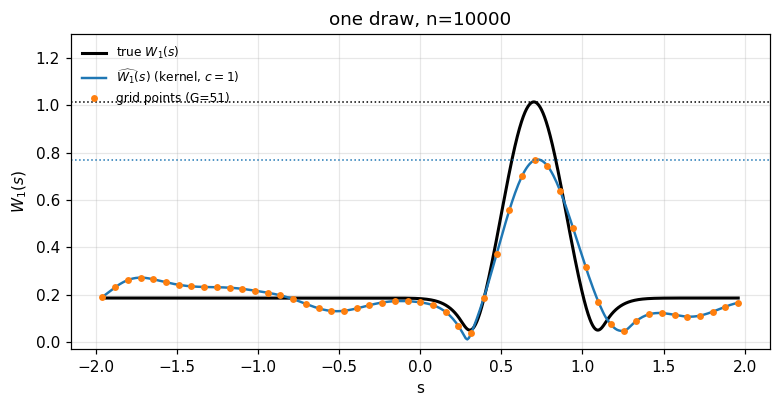


봉우리가 눌린 것이 커널 평활 편향이다: 폭 tau=0.2 인 bump 를 대역폭 h 로 문지르면
높이가 대략 tau/sqrt(tau^2+h^2) = 0.784 배로 줄어든다 (사양 6절).


In [9]:
n_demo = 10000
tau_ = model["params"]["tau"]
rng = np.random.default_rng(C.seed_of(0))
s, z = C.simulate(n_demo, model, rng)
h = C.bandwidth(n_demo, 1.0)
P = C.prep(s, z)
dense = np.linspace(-C.Z_TRIM, C.Z_TRIM, 400)
w1h = C.w1_hat(dense, P, h)
grid, G = C.grid_of(0.5, h)
rep = C.run_rep(n_demo, 1.0, 0.5, C.seed_of(0), model)

print(f"n={n_demo}  h = 1*n^(-1/5) = {h:.5f}   tau = {model['params']['tau']}  -> h/tau = {h/model['params']['tau']:.2f}")
print(f"grid: ratio=0.5 -> G={G}, delta_G={grid[1]-grid[0]:.5f}")
print(f"  supIPM_hat = {rep['sup']:.5f}   (true {T['supipm']:.5f}, err {rep['sup']-T['supipm']:+.5f})")
print(f"  EIPM_hat   = {rep['eipm']:.5f}   (true {T['eipm']:.5f}, err {rep['eipm']-T['eipm']:+.5f})")
print(f"  binning sup: " + "  ".join(f"J={J}: {v:.4f}" for J, v in rep["bins"].items()))

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.plot(T["s_grid"], T["w1"], lw=2, color="k", label=r"true $W_1(s)$")
ax.plot(dense, w1h, lw=1.6, color="C0", label=r"$\widehat{W_1}(s)$ (kernel, $c=1$)")
ax.plot(grid, C.w1_hat(grid, P, h), "o", ms=3.5, color="C1", label=f"grid points (G={G})")
ax.axhline(T["supipm"], color="k", ls=":", lw=1)
ax.axhline(rep["sup"], color="C0", ls=":", lw=1)
ax.set(xlabel="s", ylabel=r"$W_1(s)$", title=f"one draw, n={n_demo}", ylim=(-0.03, 1.30))
ax.legend(fontsize=8, loc="upper left")
fig.savefig(os.path.join(NB_DIR, "figures", "S1_single_draw.png"), bbox_inches="tight")
plt.show()
print("\n봉우리가 눌린 것이 커널 평활 편향이다: 폭 tau=0.2 인 bump 를 대역폭 h 로 문지르면"
      f"\n높이가 대략 tau/sqrt(tau^2+h^2) = {tau_/np.hypot(tau_, h):.3f} 배로 줄어든다 (사양 6절).")

## 4. Slurm 실행

| 셀 | 변화 | 고정 | 반복 |
|---|---|---|---|
| C1 수렴 | `n = [500, 1000, 2000, 5000, 10000, 20000]` | `c=1, ratio=0.5, tau=0.2` | 100 |
| C2 grid | `ratio = [0.25, 0.5, 1, 2, 4, 8]` | `n=10000, c=1, tau=0.2` | 100 |
| C3 binning | `J = [2,3,5,10,20]` vs 커널 | `n=10000` | 100 |
| C1b (보조, 사양 외) | `c = [0.25, 0.5]` × 같은 `n` | `ratio=0.5` | 100 |

seed = `1000 + 7919*r`. 한 번의 draw 로 계산 가능한 추정치(커널 sup, EIPM, binning 전부)는
**같은 워커에서 함께** 계산하므로 `(n, c, ratio)` 가 같은 설정은 파일 하나를 공유하고,
셀 간 비교는 정확히 paired 다. C1b 는 "편향이 추정량의 결함이 아니라 대역폭 선택의 결과"임을
보이기 위해 추가한 것으로, 사양의 C1~C3 는 그대로 둔 채 따로 그린다.

In [10]:
jobs = R.all_jobs()
print(f"총 설정 {len(jobs)}개 (중복 제거 후) — C1 6, C2 6(1개는 C1 과 공유), C3 는 C1/C2 의 n=10000 draw 재사용, C1b 12\n")
print(f"{'tag':<52} {'n':>6} {'c':>5} {'ratio':>6}  done")
for j in jobs:
    print(f"{j['tag']:<52} {j['n']:>6} {j['c']:>5g} {j['ratio']:>6g}  {R.is_done(j)}")

총 설정 23개 (중복 제거 후) — C1 6, C2 6(1개는 C1 과 공유), C3 는 C1/C2 의 n=10000 draw 재사용, C1b 12

tag                                                       n     c  ratio  done
bump_kappa1.2_s00.7_tau0.2__n500_c1_r0.5                500     1    0.5  True
bump_kappa1.2_s00.7_tau0.2__n1000_c1_r0.5              1000     1    0.5  True
bump_kappa1.2_s00.7_tau0.2__n2000_c1_r0.5              2000     1    0.5  True
bump_kappa1.2_s00.7_tau0.2__n5000_c1_r0.5              5000     1    0.5  True
bump_kappa1.2_s00.7_tau0.2__n10000_c1_r0.5            10000     1    0.5  True
bump_kappa1.2_s00.7_tau0.2__n20000_c1_r0.5            20000     1    0.5  True
bump_kappa1.2_s00.7_tau0.2__n10000_c1_r0.25           10000     1   0.25  True
bump_kappa1.2_s00.7_tau0.2__n10000_c1_r1              10000     1      1  True
bump_kappa1.2_s00.7_tau0.2__n10000_c1_r2              10000     1      2  True
bump_kappa1.2_s00.7_tau0.2__n10000_c1_r4              10000     1      4  True
bump_kappa1.2_s00.7_tau0.2__n10000_c1_r8      

In [11]:
t0 = time.time()
failed = R.launch(jobs, cpus=2)          # cached 설정은 건너뜀. 다시 돌리려면 force=True
assert not failed, f"실패한 설정: {failed}"
print(f"\n총 {time.time()-t0:.0f}s")
_ = R.status(jobs)

[runner] 0/23 to run (23 cached) | mode=in-allocation subprocesses | max_concurrent=8 cpus/job=2

총 0s
[runner] 23/23 configurations complete


## 5. 집계 & 그림

In [12]:
res = R.load_many(jobs)
FIG = os.path.join(NB_DIR, "figures")

def err(tag, what="sup"):
    d = res[tag]
    return d["sup_hat"] - float(d["sup_true"]) if what == "sup" else d["eipm_hat"] - float(d["eipm_true"])

rmse = lambda e: float(np.sqrt(np.mean(e ** 2)))
SUP_TRUE, EIPM_TRUE = float(res[jobs[0]["tag"]]["sup_true"]), float(res[jobs[0]["tag"]]["eipm_true"])
REPS = int(res[jobs[0]["tag"]]["reps"])
print(f"reps={REPS}  supIPM_true={SUP_TRUE:.6f}  EIPM_true={EIPM_TRUE:.6f}")
print("모든 설정이 같은 참값을 쓰는지:",
      all(abs(float(d['sup_true']) - SUP_TRUE) < 1e-12 for d in res.values()))

reps=100  supIPM_true=1.013973  EIPM_true=0.270027
모든 설정이 같은 참값을 쓰는지: True


### C1 — 수렴 (P1)

     n       h    G |  sup bias  sup rmse   sup sd |    E bias    E rmse     E sd
---------------------------------------------------------------------------------
   500  0.2885 *  29 |   -0.5046    0.5085   0.0629 |   -0.0479    0.0578   0.0326
  1000  0.2512 *  33 |   -0.4335    0.4366   0.0516 |   -0.0400    0.0465   0.0238
  2000  0.2187 *  37 |   -0.3851    0.3873   0.0418 |   -0.0363    0.0410   0.0193
  5000  0.1821    45 |   -0.3091    0.3103   0.0278 |   -0.0289    0.0319   0.0136
 10000  0.1585    51 |   -0.2541    0.2548   0.0198 |   -0.0221    0.0252   0.0121
 20000  0.1380    58 |   -0.2130    0.2137   0.0171 |   -0.0208    0.0231   0.0101
  * = h > tau (bump 폭보다 대역폭이 커서 봉우리를 해상하지 못하는 구간)

log-log 기울기 (regression of log RMSE on log n):
  sup RMSE  : -0.235
  EIPM RMSE : -0.255
  sup SD    : -0.374
  EIPM SD   : -0.315


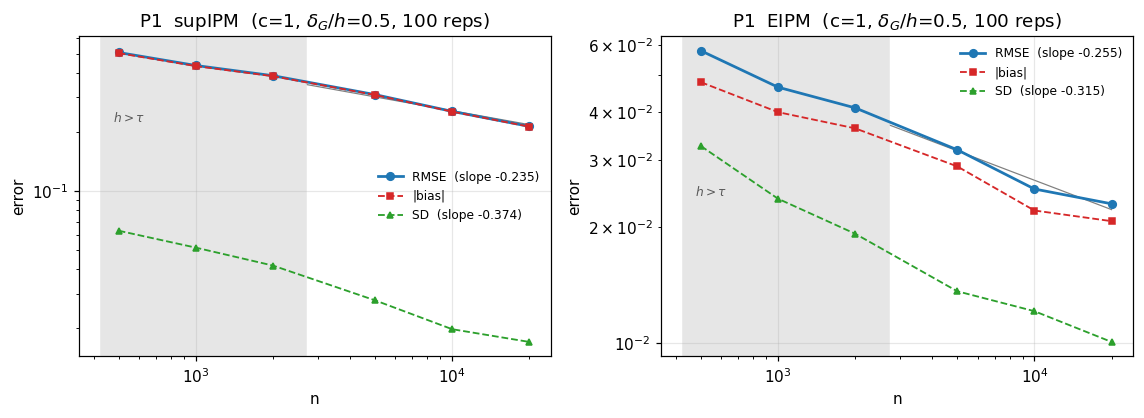

주의(사양 6절): n=500 에서 h=0.289 > tau=0.2 이므로 bump 를 해상하지 못해 하향 편향이 크다 — 버그가 아니다.
supIPM 은 noisy 한 값들의 max 라 양의 편향 성분도 있지만, 이 설정에서는 평활 편향(음)이 압도한다.


In [13]:
j1 = R.jobs_c1()
n1 = np.array([j["n"] for j in j1], float)
rows = []
for j in j1:
    d, es, ee = res[j["tag"]], err(j["tag"], "sup"), err(j["tag"], "eipm")
    rows.append((j["n"], float(d["h"]), int(d["G"]), es.mean(), rmse(es), es.std(ddof=1),
                 ee.mean(), rmse(ee), ee.std(ddof=1)))

hdr = f"{'n':>6} {'h':>7} {'G':>4} | {'sup bias':>9} {'sup rmse':>9} {'sup sd':>8} | {'E bias':>9} {'E rmse':>9} {'E sd':>8}"
print(hdr); print("-" * len(hdr))
for r in rows:
    star = " *" if r[1] > model["params"]["tau"] else "  "
    print(f"{r[0]:6d} {r[1]:7.4f}{star}{r[2]:4d} | {r[3]:+9.4f} {r[4]:9.4f} {r[5]:8.4f} | "
          f"{r[6]:+9.4f} {r[7]:9.4f} {r[8]:8.4f}")
print("  * = h > tau (bump 폭보다 대역폭이 커서 봉우리를 해상하지 못하는 구간)")

ln = np.log(n1)
slopes = {}
for k, lbl in [(4, "sup RMSE"), (7, "EIPM RMSE"), (5, "sup SD"), (8, "EIPM SD")]:
    slopes[lbl] = float(np.polyfit(ln, np.log([r[k] for r in rows]), 1)[0])
print("\nlog-log 기울기 (regression of log RMSE on log n):")
for k, v in slopes.items():
    print(f"  {k:<10}: {v:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.9))
for ax, (kr, ks, name, tv) in zip(axes, [(4, 5, "supIPM", SUP_TRUE), (7, 8, "EIPM", EIPM_TRUE)]):
    rm = np.array([r[kr] for r in rows]); sd = np.array([r[ks] for r in rows])
    ab = np.abs([r[kr - 1] for r in rows])
    sl = np.polyfit(ln, np.log(rm), 1)
    ax.loglog(n1, rm, "o-", lw=1.8, ms=5, color="C0", label=f"RMSE  (slope {sl[0]:+.3f})")
    ax.loglog(n1, ab, "s--", lw=1.2, ms=4, color="C3", label="|bias|")
    ax.loglog(n1, sd, "^--", lw=1.2, ms=4, color="C2",
              label=f"SD  (slope {np.polyfit(ln, np.log(sd), 1)[0]:+.3f})")
    ax.loglog(n1, np.exp(np.polyval(sl, ln)), "-", lw=0.8, color="0.5", zorder=0)
    bad = n1[np.array([r[1] for r in rows]) > model["params"]["tau"]]
    if bad.size:
        ax.axvspan(n1.min() * 0.85, bad.max() * 1.35, color="0.9", zorder=0)
        ax.text(n1.min() * 0.95, rm.min() * 1.05, r"$h>\tau$", fontsize=8, color="0.35")
    ax.set(xlabel="n", ylabel="error", title=f"P1  {name}  (c=1, $\\delta_G/h$=0.5, {REPS} reps)")
    ax.legend(fontsize=8)
fig.savefig(os.path.join(FIG, "P1_convergence.png"), bbox_inches="tight")
plt.show()
print("주의(사양 6절): n=500 에서 h=0.289 > tau=0.2 이므로 bump 를 해상하지 못해 하향 편향이 크다 — 버그가 아니다.\n"
      "supIPM 은 noisy 한 값들의 max 라 양의 편향 성분도 있지만, 이 설정에서는 평활 편향(음)이 압도한다.")

### C1b — 보조: 대역폭 상수 `c` 를 줄이면 (사양 외 추가)

C1 의 큰 하향 편향이 *추정량*의 문제인지 *대역폭 선택*의 문제인지 가르기 위한 확인.
`c` 는 여전히 `h = c n^(-1/5)` 형태를 유지한다.

    c      n       h  sup bias  sup rmse |    E bias    E rmse
    1    500  0.2885   -0.5046    0.5085 |   -0.0479    0.0578
    1   1000  0.2512   -0.4335    0.4366 |   -0.0400    0.0465
    1   2000  0.2187   -0.3851    0.3873 |   -0.0363    0.0410
    1   5000  0.1821   -0.3091    0.3103 |   -0.0289    0.0319
    1  10000  0.1585   -0.2541    0.2548 |   -0.0221    0.0252
    1  20000  0.1380   -0.2130    0.2137 |   -0.0208    0.0231

  0.5    500  0.1443   -0.2243    0.2420 |   +0.0101    0.0346
  0.5   1000  0.1256   -0.1673    0.1850 |   +0.0058    0.0250
  0.5   2000  0.1093   -0.1425    0.1542 |   -0.0022    0.0216
  0.5   5000  0.0910   -0.1068    0.1133 |   -0.0054    0.0156
  0.5  10000  0.0792   -0.0788    0.0836 |   -0.0038    0.0136
  0.5  20000  0.0690   -0.0683    0.0723 |   -0.0062    0.0129

 0.25    500  0.0721   -0.0275    0.1229 |   +0.0620    0.0698
 0.25   1000  0.0628   -0.0080    0.1148 |   +0.0409    0.0472
 0.25   2000  0.0547   -0.0198    0.0817 |   +0.0214 

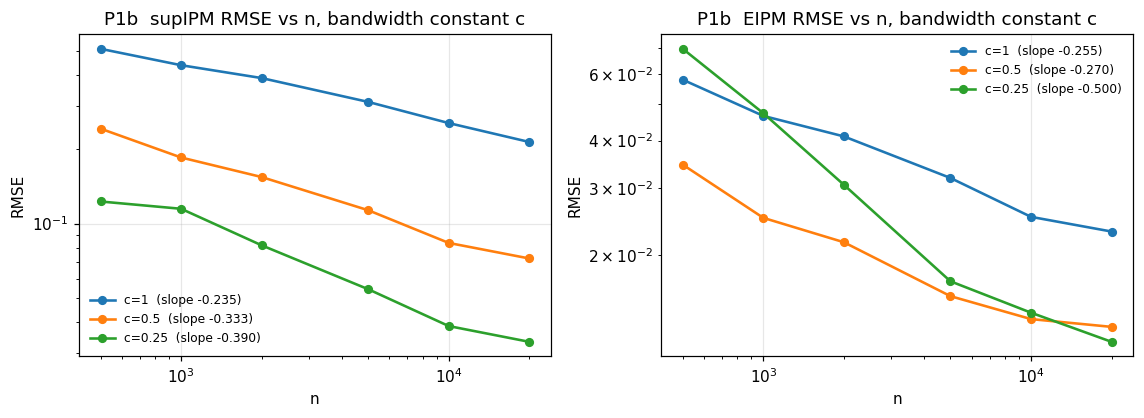

In [14]:
cs = [1.0] + R.C_EXTRA
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.9))
print(f"{'c':>5} {'n':>6} {'h':>7} {'sup bias':>9} {'sup rmse':>9} | {'E bias':>9} {'E rmse':>9}")
for ci, cc in enumerate(sorted(cs, reverse=True)):
    js = [R.job(n, cc, R.RATIO_BASE) for n in R.N_LIST]
    rm_s, rm_e = [], []
    for j in js:
        es, ee = err(j["tag"], "sup"), err(j["tag"], "eipm")
        rm_s.append(rmse(es)); rm_e.append(rmse(ee))
        print(f"{cc:5g} {j['n']:6d} {float(res[j['tag']]['h']):7.4f} {es.mean():+9.4f} {rmse(es):9.4f} | "
              f"{ee.mean():+9.4f} {rmse(ee):9.4f}")
    for ax, rm, name in zip(axes, (rm_s, rm_e), ("supIPM", "EIPM")):
        sl = np.polyfit(ln, np.log(rm), 1)[0]
        ax.loglog(n1, rm, "o-", ms=5, lw=1.7, color=f"C{ci}", label=f"c={cc:g}  (slope {sl:+.3f})")
    print()
for ax, name in zip(axes, ("supIPM", "EIPM")):
    ax.set(xlabel="n", ylabel="RMSE", title=f"P1b  {name} RMSE vs n, bandwidth constant c")
    ax.legend(fontsize=8)
fig.savefig(os.path.join(FIG, "P1b_bandwidth.png"), bbox_inches="tight")
plt.show()

### C2 — grid 간격 (P2)

 delta_G/h     G |  sup bias  sup rmse   sup sd |  EIPM rmse
      0.25   100 |   -0.2538    0.2546   0.0203 |     0.0252
       0.5    51 |   -0.2541    0.2548   0.0198 |     0.0252
         1    26 |   -0.2541    0.2548   0.0198 |     0.0252
         2    14 |   -0.2616    0.2624   0.0209 |     0.0252
         4     8 |   -0.3511    0.3518   0.0227 |     0.0252
         8     5 |   -0.6289    0.6294   0.0249 |     0.0252

EIPM_hat 은 grid 와 무관 (관측 s_i 에서 평가) -> 모든 ratio 에서 동일한가? True


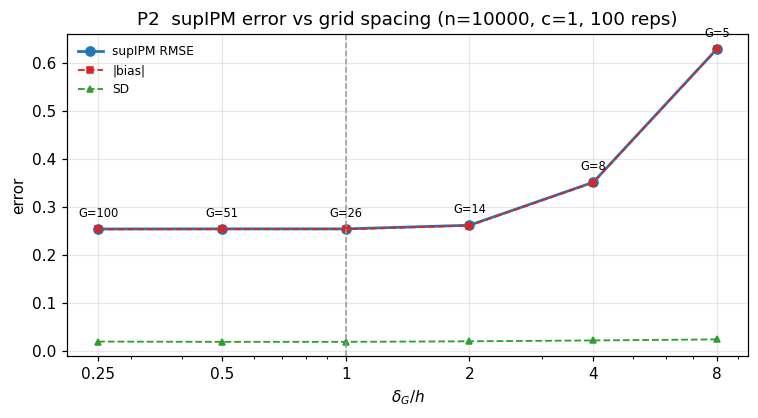

ratio<=1 구간 RMSE 변동폭 = 0.00019 (RMSE 자체의 0.08%),  ratio=8 에서는 2.47배로 악화 -> elbow 는 ratio ~ 1~2.


In [15]:
j2 = R.jobs_c2()
ratios = np.array([j["ratio"] for j in j2], float)
print(f"{'delta_G/h':>10} {'G':>5} | {'sup bias':>9} {'sup rmse':>9} {'sup sd':>8} | {'EIPM rmse':>10}")
rows2 = []
for j in j2:
    d, es, ee = res[j["tag"]], err(j["tag"], "sup"), err(j["tag"], "eipm")
    rows2.append((j["ratio"], int(d["G"]), es.mean(), rmse(es), es.std(ddof=1), rmse(ee)))
    print(f"{j['ratio']:10g} {int(d['G']):5d} | {es.mean():+9.4f} {rmse(es):9.4f} {es.std(ddof=1):8.4f} | {rmse(ee):10.4f}")

base = res[R.job(R.N_BASE, R.C_BASE, R.RATIO_BASE)["tag"]]["eipm_hat"]
same = all(np.array_equal(res[j["tag"]]["eipm_hat"], base) for j in j2)
print(f"\nEIPM_hat 은 grid 와 무관 (관측 s_i 에서 평가) -> 모든 ratio 에서 동일한가? {same}")

rm2 = np.array([r[3] for r in rows2])
fig, ax = plt.subplots(figsize=(7.0, 3.9))
ax.plot(ratios, rm2, "o-", lw=1.8, ms=6, color="C0", label="supIPM RMSE")
ax.plot(ratios, np.abs([r[2] for r in rows2]), "s--", lw=1.2, ms=4, color="C3", label="|bias|")
ax.plot(ratios, [r[4] for r in rows2], "^--", lw=1.2, ms=4, color="C2", label="SD")
ax.set_xscale("log"); ax.set_xticks(ratios); ax.set_xticklabels([f"{r:g}" for r in ratios])
for r, g, y in zip(ratios, [r[1] for r in rows2], rm2):
    ax.annotate(f"G={g}", (r, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=7.5)
ax.axvline(1.0, color="0.6", ls="--", lw=1)
ax.set(xlabel=r"$\delta_G/h$", ylabel="error",
       title=f"P2  supIPM error vs grid spacing (n={R.N_BASE}, c=1, {REPS} reps)")
ax.legend(fontsize=8)
fig.savefig(os.path.join(FIG, "P2_grid.png"), bbox_inches="tight")
plt.show()

flat = rm2[ratios <= 1].max() - rm2[ratios <= 1].min()
print(f"ratio<=1 구간 RMSE 변동폭 = {flat:.5f} (RMSE 자체의 {100*flat/rm2[ratios<=1].mean():.2f}%),"
      f"  ratio=8 에서는 {rm2[-1]/rm2[0]:.2f}배로 악화 -> elbow 는 ratio ~ 1~2.")

### C3 — binning 비교 (P3)

n=10000, 100 reps, supIPM_true=1.01397

          method      bias      rmse        sd   obs/bin
      kernel c=1   -0.2541    0.2548    0.0198         -
     binning J=2   -0.8275    0.8276    0.0104      5000
     binning J=3   -0.7019    0.7020    0.0152      3333
     binning J=5   -0.4663    0.4670    0.0258      2000
    binning J=10   -0.1200    0.1229    0.0270      1000
    binning J=20   -0.0692    0.0794    0.0391       500

(진단, 사양 외) 커널 grid 와 같은 [-z,z] 안에서만 분위수 구간을 잡은 경우:
binning-trim J=2   -0.8079    0.8080    0.0105
binning-trim J=3   -0.6637    0.6638    0.0146
binning-trim J=5   -0.5053    0.5060    0.0282
binning-trim J=10   -0.1420    0.1456    0.0322
binning-trim J=20   -0.0217    0.0456    0.0403


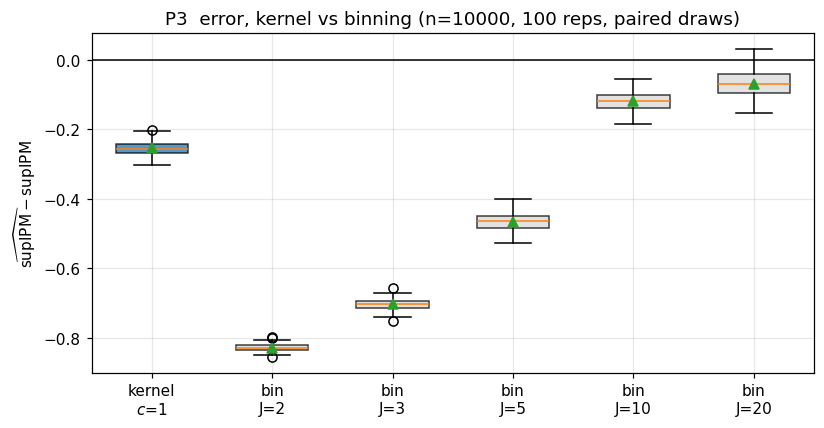

In [16]:
jb = R.job(R.N_BASE, R.C_BASE, R.RATIO_BASE)
d = res[jb["tag"]]
Js = [int(x) for x in d["js"]]
e_ker = err(jb["tag"], "sup")
e_bin = d["bin_hat"] - SUP_TRUE            # (J, reps)
e_bit = d["bin_trim_hat"] - SUP_TRUE

print(f"n={R.N_BASE}, {REPS} reps, supIPM_true={SUP_TRUE:.5f}\n")
print(f"{'method':>16} {'bias':>9} {'rmse':>9} {'sd':>9} {'obs/bin':>9}")
print(f"{'kernel c=1':>16} {e_ker.mean():+9.4f} {rmse(e_ker):9.4f} {e_ker.std(ddof=1):9.4f} {'-':>9}")
for k, J in enumerate(Js):
    print(f"{'binning J='+str(J):>16} {e_bin[k].mean():+9.4f} {rmse(e_bin[k]):9.4f} "
          f"{e_bin[k].std(ddof=1):9.4f} {R.N_BASE//J:9d}")
print("\n(진단, 사양 외) 커널 grid 와 같은 [-z,z] 안에서만 분위수 구간을 잡은 경우:")
for k, J in enumerate(Js):
    print(f"{'binning-trim J='+str(J):>16} {e_bit[k].mean():+9.4f} {rmse(e_bit[k]):9.4f} {e_bit[k].std(ddof=1):9.4f}")

fig, ax = plt.subplots(figsize=(7.6, 4.0))
data = [e_ker] + [e_bin[k] for k in range(len(Js))]
labels = ["kernel\n$c$=1"] + [f"bin\nJ={J}" for J in Js]
bp = ax.boxplot(data, tick_labels=labels, showmeans=True, widths=0.6, patch_artist=True)
for i, b in enumerate(bp["boxes"]):
    b.set(facecolor="C0" if i == 0 else "0.85", alpha=0.75)
ax.axhline(0, color="k", lw=1)
ax.set(ylabel=r"$\widehat{\mathrm{supIPM}} - \mathrm{supIPM}$",
       title=f"P3  error, kernel vs binning (n={R.N_BASE}, {REPS} reps, paired draws)")
fig.savefig(os.path.join(FIG, "P3_binning.png"), bbox_inches="tight")
plt.show()

### bias vs n (한 줄 표)

In [17]:
print("supIPM bias : " + "  ".join(f"n={int(r[0])}:{r[3]:+.4f}" for r in rows))
print("EIPM   bias : " + "  ".join(f"n={int(r[0])}:{r[6]:+.4f}" for r in rows))
print("supIPM rmse : " + "  ".join(f"n={int(r[0])}:{r[4]:.4f}" for r in rows))
print("EIPM   rmse : " + "  ".join(f"n={int(r[0])}:{r[7]:.4f}" for r in rows))

supIPM bias : n=500:-0.5046  n=1000:-0.4335  n=2000:-0.3851  n=5000:-0.3091  n=10000:-0.2541  n=20000:-0.2130
EIPM   bias : n=500:-0.0479  n=1000:-0.0400  n=2000:-0.0363  n=5000:-0.0289  n=10000:-0.0221  n=20000:-0.0208
supIPM rmse : n=500:0.5085  n=1000:0.4366  n=2000:0.3873  n=5000:0.3103  n=10000:0.2548  n=20000:0.2137
EIPM   rmse : n=500:0.0578  n=1000:0.0465  n=2000:0.0410  n=5000:0.0319  n=10000:0.0252  n=20000:0.0231


## 6. 정리 (실행 결과)

`supIPM_true = 1.013973`, `EIPM_true = 0.270027`, 설정당 100 반복, 전체 스윕 약 110 초(16 CPU 할당).

1. **참값 검증** — linear 닫힌 형태와 최대 차이 `5e-8 ~ 7e-7` (< `1e-6`, 통과).
   `u` 격자는 2001점부터 이미 9자리 수렴, 범위 $\pm 8$ 로 충분. GH-101 의 supIPM 오차는
   `-8.2e-5` 로 가장 작은 RMSE(0.033)보다 세 자릿수 작다 → 사양대로 101 노드 유지.
   bump 의 sup 은 $s=0.7$ (구간 **내부**)에서 달성 → C2 가 의미를 가진다.

2. **C1 / P1 — 수렴** — supIPM RMSE `0.509 → 0.214` ($n$: 500 → 20000), 기울기 **-0.235**;
   EIPM RMSE `0.058 → 0.023`, 기울기 **-0.255**. 둘 다 단조 감소하지만 `c=1` 에서는
   $|{\rm bias}|/{\rm RMSE} > 0.99$ 로 **평활 편향이 지배**한다: $h=n^{-1/5}$ 가 bump 폭
   $\tau=0.2$ 와 같은 크기라 봉우리 높이가 $\tau/\sqrt{\tau^2+h^2}$ 배로 눌린다
   ($n$=10000 에서 0.78배). 기울기가 $-1/5$ 근처인 것도 분산이 아니라 $h$ 의 감소율을 따라간
   결과다. $n \le 2000$ 은 $h>\tau$ 구간(회색). **사양 6절이 예고한 그대로이며 버그가 아니다.**
   SD 는 `0.063 → 0.017` (기울기 -0.374) 로 훨씬 빠르게 준다.

3. **C1b — 편향의 출처** — 같은 추정량에서 $c$ 만 줄이면 $n$=20000 기준 supIPM RMSE
   `0.214 (c=1) → 0.072 (c=0.5) → 0.033 (c=0.25)`, 기울기도 `-0.235 → -0.333 → -0.390` 으로
   가팔라진다. 즉 C1 의 큰 편향은 추정량의 결함이 아니라 **대역폭 상수 선택**의 결과다.
   공짜는 아니다: $c$=0.25, $n$=500 에서는 bias `-0.028` 인데 RMSE 는 `0.123` 으로 분산이 지배한다.

4. **C2 / P2 — grid 간격** — $\delta_G/h \le 1$ 구간에서 RMSE 변동은 0.08% (사실상 평평),
   $\delta_G/h$ = 2 에서 +3%, 4 에서 +38%, 8 에서 +147%. **elbow 는 ratio ≈ 1~2**.
   grid 는 대역폭보다 촘촘하기만 하면 되고 그 이상은 계산 낭비다.
   `EIPM_hat` 은 관측 $s_i$ 에서 평가하므로 grid 와 무관 — 6개 ratio 에서 값이 완전히 동일함을 확인.

5. **C3 / P3 — binning 비교** — 굵은 binning($J\le5$: bias `-0.83 ~ -0.47`)은 커널(`-0.254`)보다
   훨씬 나쁘다. 구간 안에서 $\mu$ 가 평균되어 봉우리가 사라지기 때문. 반대로 $J$=10, 20 은
   bias `-0.120`, `-0.069` 로 이 설정의 커널($c$=1)보다 **낫다** — $n$=10000 에서 분위수 구간이
   $s=0.7$ 근처에서 $h=0.158$ 보다 좁아 봉우리를 더 잘 해상하기 때문이고, 대신 SD 는
   `0.020 → 0.039` 로 커진다. 즉 P3 는 "커널 vs binning" 의 우열이 아니라 **유효 해상도**
   비교로 읽어야 한다 (C1b 와 함께 보면 분명하다).

### 재현

```bash
cd "Fair representation/sup_IPM/notebook"
rm -rf results                     # 캐시를 지워야 실제로 다시 계산한다
srun --cpus-per-task=16 --partition=idea --time=04:00:00 \
    /usr/local/miniconda3/envs/nine/bin/jupyter nbconvert --to notebook --execute \
    --inplace --ExecutePreprocessor.timeout=7200 s1.ipynb
```

`s1_runner.py` 는 단독으로도 쓸 수 있다: `python s1_runner.py all|c1|c2|c3|c1b [--dry] [--force]`.